In [162]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("abdulhasibuddin/uc-merced-land-use-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'uc-merced-land-use-dataset' dataset.
Path to dataset files: /kaggle/input/uc-merced-land-use-dataset


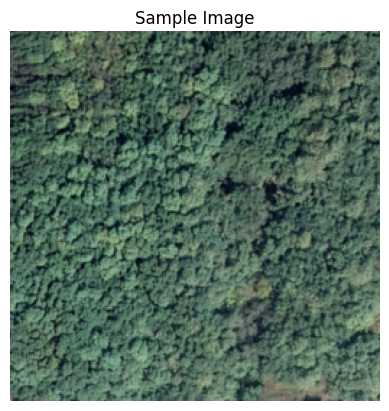

In [163]:
import os
classes = {
    "buildings": "buildings",
    "roads": "overpass",     # or "freeway"
    "vegetation": "forest",  # or "chaparral"
    "water": "river"
}

import cv2
import matplotlib.pyplot as plt
import random

path="/kaggle/input/uc-merced-land-use-dataset/UCMerced_LandUse/Images"

def load_random_image(class_name):
    class_path = os.path.join(path, class_name)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image

image = load_random_image("forest")

plt.imshow(image)
plt.title("Sample Image")
plt.axis("off")

hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)


Vegetation Mask

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

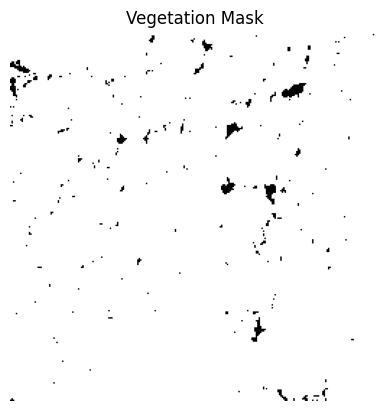

In [164]:
import numpy as np

# Broader vegetation range (includes dry + dark greens)
lower_veg = np.array([20, 20, 20])
upper_veg = np.array([100, 255, 200])

mask_green = cv2.inRange(hsv, lower_veg, upper_veg)

plt.imshow(mask_green, cmap='gray')
plt.title("Vegetation Mask")
plt.axis("off")

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

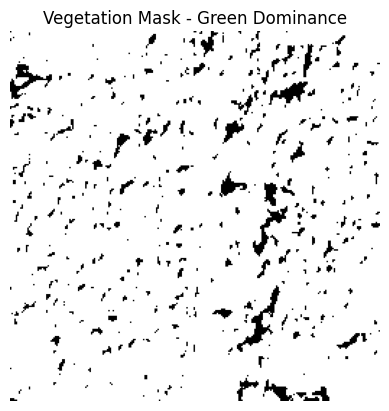

In [165]:
# Extract channels
R = image[:,:,0].astype(float)
G = image[:,:,1].astype(float)
B = image[:,:,2].astype(float)

# Vegetation if Green is dominant
veg_mask = (G > R) & (G > B)

mask_green = veg_mask.astype(np.uint8) * 255

plt.imshow(mask_green, cmap='gray')
plt.title("Vegetation Mask - Green Dominance")
plt.axis("off")

Water Mask

In [166]:
lower_blue = np.array([90, 50, 50])
upper_blue = np.array([130, 255, 255])

mask_blue = cv2.inRange(hsv, lower_blue, upper_blue)

Building Mask

In [167]:
lower_building = np.array([10, 50, 50])
upper_building = np.array([25, 255, 255])

mask_building = cv2.inRange(hsv, lower_building, upper_building)

Road Mask

In [168]:
lower_gray = np.array([0, 0, 50])
upper_gray = np.array([180, 50, 200])

mask_road = cv2.inRange(hsv, lower_gray, upper_gray)

Area Percentage

In [169]:
def calculate_percentage(mask, image):
    area = cv2.countNonZero(mask)
    total = image.shape[0] * image.shape[1]
    return (area / total) * 100

print("Vegetation:", calculate_percentage(mask_green, image))
print("Water:", calculate_percentage(mask_blue, image))
print("Buildings:", calculate_percentage(mask_building, image))
print("Roads:", calculate_percentage(mask_road, image))

Vegetation: 92.974853515625
Water: 1.82037353515625
Buildings: 0.0
Roads: 13.55438232421875


In [170]:
kernel = np.ones((5,5), np.uint8)

mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_CLOSE, kernel)
mask_green = cv2.morphologyEx(mask_green, cv2.MORPH_OPEN, kernel)

In [171]:
import numpy as np

# HSV range for vegetation (green)
lower_green = np.array([25, 40, 40])
upper_green = np.array([90, 255, 255])

def calculate_percentage(mask, image):
    area = cv2.countNonZero(mask)
    total = image.shape[0] * image.shape[1]
    return (area / total) * 100

def process_class(class_name, n=10):
    class_path = os.path.join(path, class_name)
    images = os.listdir(class_path)[:n]

    total_percent = 0

    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

        mask = cv2.inRange(hsv, lower_green, upper_green)
        total_percent += calculate_percentage(mask, image)

    return total_percent/n

print("Average vegetation in forest class:", process_class("forest"))

Average vegetation in forest class: 50.67779541015625


In [172]:
veg_forest = process_class("forest")
veg_residential = process_class("denseresidential")

print("Vegetation Drop:", veg_forest - veg_residential)

Vegetation Drop: 39.0057373046875
